In [ ]:
import kagglehub
import os
from PIL import Image
import matplotlib.pyplot as plt
import random
import numpy as np
from tqdm import tqdm
from tensorflow.keras import layers
import tensorflow as tf
import time


In [45]:
path = kagglehub.dataset_download("kushsheth/face-vae")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/face-vae


In [16]:
dataset_path = "/kaggle/input/face-vae/img_align_celeba/img_align_celeba"


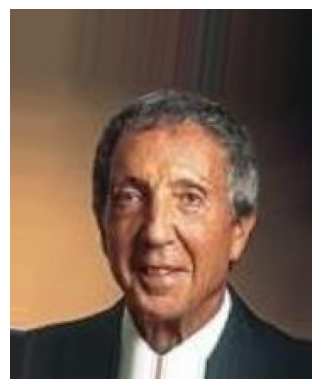

In [19]:

img_path = os.path.join(dataset_path,"144556.jpg") 
img = Image.open(img_path)

plt.imshow(img)
plt.axis("off")
plt.show()


In [20]:

dataset_path
image_extensions = [".jpg", ".jpeg", ".png", ".bmp"]
image_count = 0

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if any(file.lower().endswith(ext) for ext in image_extensions):
            image_count += 1

print(f"Total number of images: {image_count}")


Total number of images: 202599


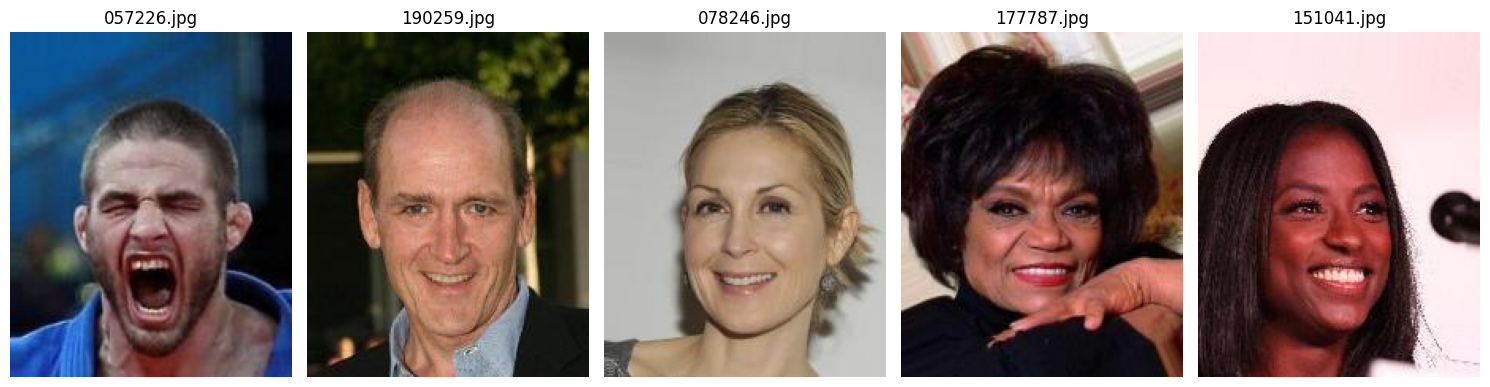

In [22]:
image_dir = dataset_path

image_files = os.listdir(image_dir)

sample_files = random.sample(image_files, 5)

plt.figure(figsize=(15, 5))
for i, filename in enumerate(sample_files):
    img_path = os.path.join(image_dir, filename)
    img = Image.open(img_path)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(filename)
plt.tight_layout()
plt.show()


In [23]:
def apply_center_mask(image, mask_size):
    """
    Applies a black square mask to the center of the image.
    """
    img_np = np.array(image).copy()
    h, w, _ = img_np.shape

    top = (h - mask_size) // 2
    left = (w - mask_size) // 2

    img_np[top:top+mask_size, left:left+mask_size, :] = 0
    return Image.fromarray(img_np)


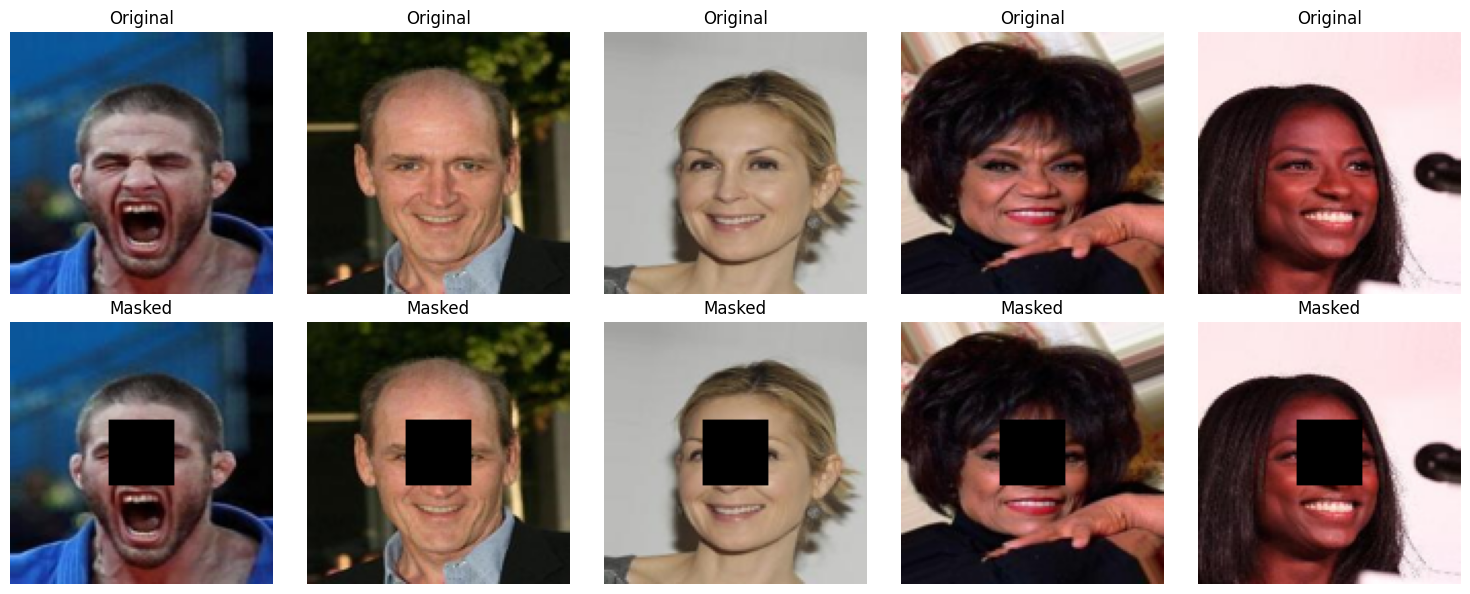

In [25]:
resize_size = 128
mask_size = 32

plt.figure(figsize=(15, 6))
for i, filename in enumerate(sample_files):
    img_path = os.path.join(image_dir, filename)
    img = Image.open(img_path).resize((resize_size, resize_size)).convert("RGB")
    masked_img = apply_center_mask(img, mask_size=mask_size)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(2, 5, i + 6)
    plt.imshow(masked_img)
    plt.axis("off")
    plt.title("Masked")

plt.tight_layout()
plt.show()


In [26]:
def preprocess_dataset(image_dir, image_files, img_size=128, mask_size=40, limit=None):
    """
    Loads and preprocesses images.
    Returns: masked images (X) and originals (Y) as NumPy arrays.
    """
    X, Y = [], []

    if limit:
        image_files = image_files[:limit]

    for fname in tqdm(image_files):
        path = os.path.join(image_dir, fname)
        img = Image.open(path).resize((img_size, img_size)).convert("RGB")

        masked_img = apply_center_mask(img, mask_size)

        X.append(np.array(masked_img) / 255.0)
        Y.append(np.array(img) / 255.0)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)


In [27]:
from sklearn.model_selection import train_test_split

train_files, test_files = train_test_split(image_files, test_size=0.2)
val_files, test_files = train_test_split(test_files, test_size=0.5)

X_train, Y_train = preprocess_dataset(image_dir, train_files, limit=5000)
X_val, Y_val = preprocess_dataset(image_dir, val_files, limit=1000)
X_test, Y_test = preprocess_dataset(image_dir, test_files, limit=500)

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_val shape:", X_val.shape)
print("Y_val shape:", Y_val.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)


100%|██████████| 500/500 [00:04<00:00, 121.61it/s]


X_train shape: (5000, 128, 128, 3)
Y_train shape: (5000, 128, 128, 3)
X_val shape: (1000, 128, 128, 3)
Y_val shape: (1000, 128, 128, 3)
X_test shape: (500, 128, 128, 3)
Y_test shape: (500, 128, 128, 3)


In [28]:
device = '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0'
device

'/GPU:0'

In [29]:
def build_generator(img_size=128):
    input_img = layers.Input(shape=(img_size, img_size, 3))

    e1 = layers.Conv2D(64, 4, strides=2, padding='same', activation='relu')(input_img)  # 64x64
    e1 = layers.BatchNormalization()(e1)

    e2 = layers.Conv2D(128, 4, strides=2, padding='same', activation='relu')(e1)  # 32x32
    e2 = layers.BatchNormalization()(e2)

    e3 = layers.Conv2D(256, 4, strides=2, padding='same', activation='relu')(e2)  # 16x16
    e3 = layers.BatchNormalization()(e3)

    b = layers.Conv2D(512, 4, strides=2, padding='same', activation='relu')(e3)  # 8x8
    b = layers.BatchNormalization()(b)

    d1 = layers.Conv2DTranspose(256, 4, strides=2, padding='same', activation='relu')(b)  # 16x16
    d1 = layers.BatchNormalization()(d1)
    d1 = layers.Concatenate()([d1, e3])

    d2 = layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu')(d1)  # 32x32
    d2 = layers.BatchNormalization()(d2)
    d2 = layers.Concatenate()([d2, e2])

    d3 = layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu')(d2)  # 64x64
    d3 = layers.BatchNormalization()(d3)
    d3 = layers.Concatenate()([d3, e1])

    output = layers.Conv2DTranspose(3, 4, strides=2, padding='same', activation='sigmoid')(d3)  # 128x128

    return tf.keras.Model(input_img, output, name="generator")


In [30]:


def build_discriminator(img_size=128):
    input_img = layers.Input(shape=(img_size, img_size, 3))

    x = layers.Conv2D(64, 4, strides=2, padding='same')(input_img)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    x = layers.Conv2D(512, 4, strides=1, padding='same')(x)  # Reduce spatially but keep detail
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)

    output = layers.Conv2D(1, 4, strides=1, padding='same', activation='sigmoid')(x)

    return tf.keras.Model(input_img, output, name="discriminator")


In [31]:

bce = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = bce(tf.ones_like(real_output), real_output)
    fake_loss = bce(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output, real_images, generated_images, l1_weight=100):
    adv_loss = bce(tf.ones_like(fake_output), fake_output)
    l1_loss = tf.reduce_mean(tf.abs(real_images - generated_images))
    return adv_loss + l1_weight * l1_loss


In [32]:
generator = build_generator(img_size=128)
discriminator = build_discriminator(img_size=128)


In [33]:
gen_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)


In [34]:
@tf.function
def train_step(masked_images, real_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(masked_images, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output, real_images, generated_images)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


In [35]:

def train(dataset, epochs=10, batch_size=32):
    for epoch in range(epochs):
        start = time.time()
        print(f"Epoch {epoch + 1}/{epochs}")
        gen_loss_avg, disc_loss_avg = 0, 0
        num_batches = len(dataset) // batch_size

        for i in range(0, len(dataset), batch_size):
            x_batch = X_train[i:i+batch_size]
            y_batch = Y_train[i:i+batch_size]
            g_loss, d_loss = train_step(x_batch, y_batch)
            gen_loss_avg += g_loss.numpy()
            disc_loss_avg += d_loss.numpy()

        print(f"Gen Loss: {gen_loss_avg / num_batches:.4f}, Disc Loss: {disc_loss_avg / num_batches:.4f}, Time: {time.time() - start:.2f}s\n")


In [36]:
train(X_train, epochs=20, batch_size=32)


Epoch 1/20
Gen Loss: 7.7023, Disc Loss: 1.2632, Time: 51.30s

Epoch 2/20
Gen Loss: 5.0000, Disc Loss: 1.3286, Time: 36.20s

Epoch 3/20
Gen Loss: 4.4994, Disc Loss: 1.3346, Time: 37.23s

Epoch 4/20
Gen Loss: 4.3446, Disc Loss: 1.3312, Time: 37.38s

Epoch 5/20
Gen Loss: 4.1868, Disc Loss: 1.3374, Time: 37.16s

Epoch 6/20
Gen Loss: 4.1294, Disc Loss: 1.3287, Time: 37.34s

Epoch 7/20
Gen Loss: 3.9521, Disc Loss: 1.3592, Time: 37.24s

Epoch 8/20
Gen Loss: 3.9214, Disc Loss: 1.3344, Time: 37.24s

Epoch 9/20
Gen Loss: 3.8451, Disc Loss: 1.3428, Time: 37.30s

Epoch 10/20
Gen Loss: 3.7373, Disc Loss: 1.3450, Time: 37.28s

Epoch 11/20
Gen Loss: 3.6656, Disc Loss: 1.3492, Time: 37.26s

Epoch 12/20
Gen Loss: 3.6273, Disc Loss: 1.3515, Time: 37.23s

Epoch 13/20
Gen Loss: 3.5354, Disc Loss: 1.3590, Time: 37.26s

Epoch 14/20
Gen Loss: 3.4788, Disc Loss: 1.3441, Time: 37.26s

Epoch 15/20
Gen Loss: 3.4153, Disc Loss: 1.3528, Time: 37.24s

Epoch 16/20
Gen Loss: 3.5043, Disc Loss: 1.3424, Time: 37.22s

E

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


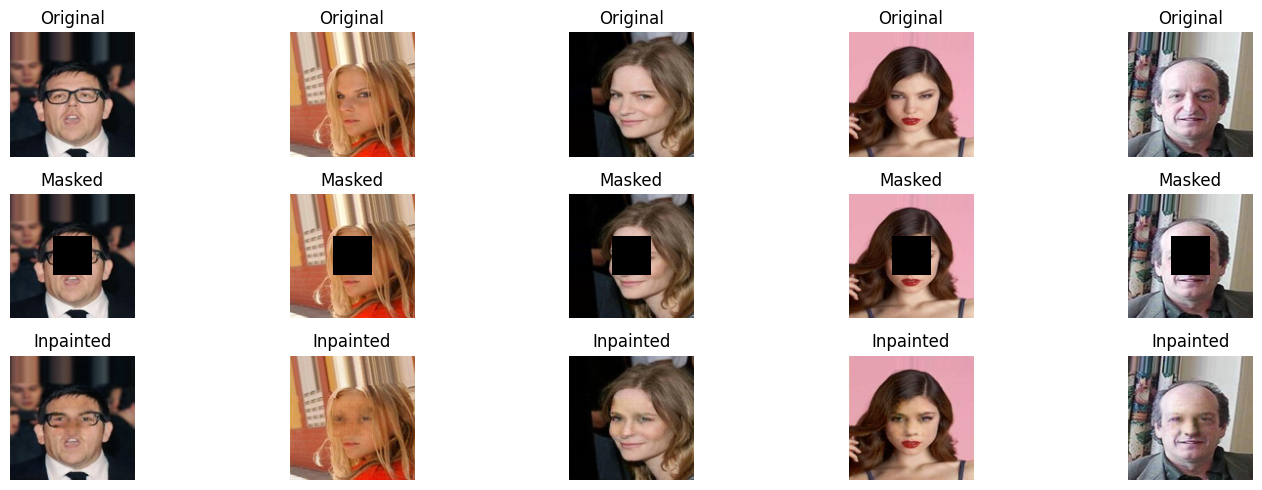

In [37]:
reconstructed = generator.predict(X_test[:5])

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(Y_test[i])
    plt.axis("off")
    plt.title("Original")

    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test[i])
    plt.axis("off")
    plt.title("Masked")

    plt.subplot(3, 5, i + 11)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    plt.title("Inpainted")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


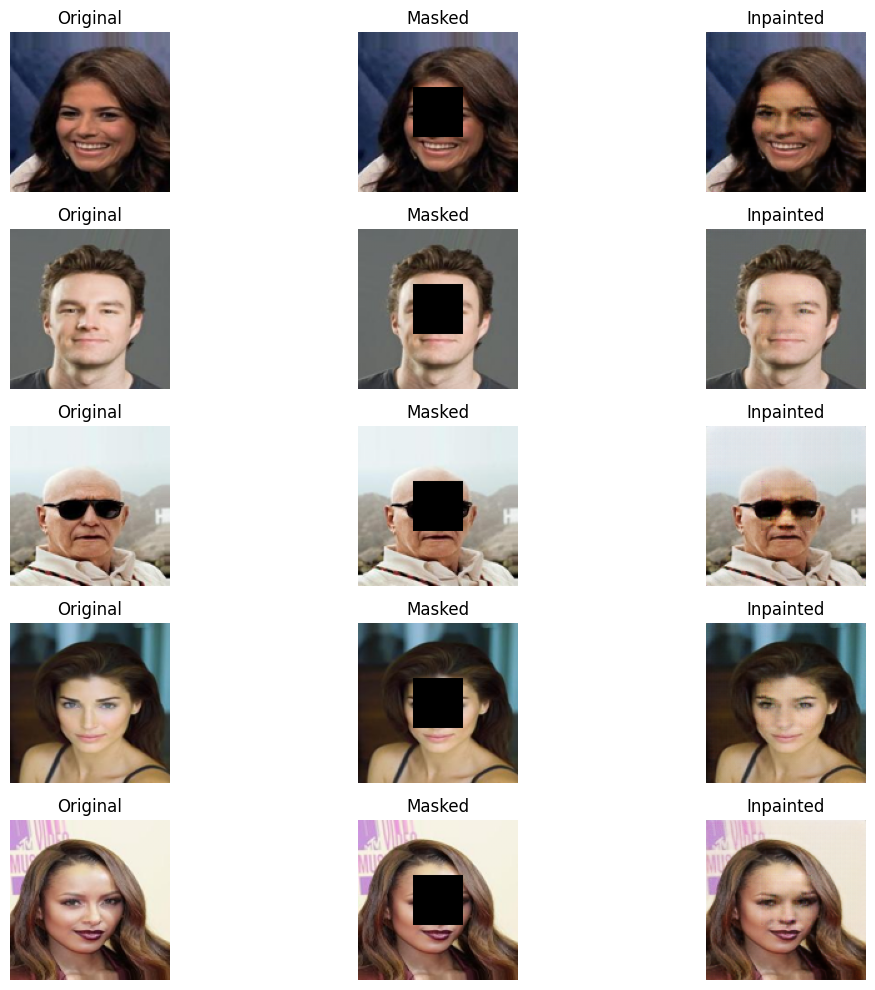

In [44]:
indices = random.sample(range(len(X_test)), 5)

input_batch = np.array([X_test[i] for i in indices])
reconstructed = generator.predict(input_batch)

plt.figure(figsize=(12, 10))
for i, idx in enumerate(indices):
    plt.subplot(5, 3, i*3 + 1)
    plt.imshow(Y_test[idx])
    plt.axis("off")
    plt.title("Original")

    plt.subplot(5, 3, i*3 + 2)
    plt.imshow(X_test[idx])
    plt.axis("off")
    plt.title("Masked")

    plt.subplot(5, 3, i*3 + 3)
    plt.imshow(reconstructed[i])
    plt.axis("off")
    plt.title("Inpainted")

plt.tight_layout()
plt.show()
